In [ ]:
!pip install python-whois

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 3.6 MB/s eta 0:00:00


In [ ]:
import re
import urllib.parse
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support, roc_auc_score
import torch.nn as nn
import ssl, socket, datetime
import whois
from urllib.parse import urlparse
import requests
from datetime import datetime

In [ ]:
from zipfile import ZipFile

zip_path = "/content/phish_model_weighted.zip"
with ZipFile(zip_path, 'r') as z:
    z.extractall("./")


In [ ]:
def preprocess_url(url: str, max_length: int = 256) -> str:
    if not isinstance(url, str):
        return "[EMPTY]"
    try:
        url = urllib.parse.unquote(url)
    except Exception:
        pass
    url = url.strip().strip('\'"')
    url = re.sub(r"/{2,}", "/", url)
    url = re.sub(r"\.{2,}", ".", url)
    url = re.sub(r"[^A-Za-z0-9:/?=.&_%@\-]", "", url)
    url = url.rstrip("./")
    if url != "" and not re.match(r"^[a-zA-Z]+://", url):
        url = "http://" + url
    if len(url) > max_length:
        url = url[:max_length]
    return url or "[EMPTY]"


In [ ]:
def check_ssl(url):
    try:
        if not url.startswith("http"):
            url = "https://" + url

        # Use crt.sh to check if a valid certificate exists
        hostname = url.split("://")[1].split("/")[0]
        r = requests.get(f"https://crt.sh/?q={hostname}&output=json", timeout=5)

        if r.status_code != 200 or r.text.strip() == "":
            return 0  # no certificate record → suspicious

        return 1  # valid certificate found
    except:
        return 1

In [ ]:
def check_domain_age(url):
    try:
        if not url.startswith("http"):
            url = "https://" + url

        hostname = url.split("://")[1].split("/")[0]
        w = whois.whois(hostname)

        # whois date formats differ — take earliest creation date
        creation = w.creation_date
        if isinstance(creation, list):
            creation = creation[0]

        age_days = (datetime.utcnow() - creation).days

        # RULE: Domains younger than 180 days are suspicious
        return 1 if age_days < 180 else 0

    except:
        # if WHOIS lookup fails → suspicious
        return 0

In [ ]:
def reputation_check(url):
    try:
        hostname = urlparse(url).hostname or url

        r = requests.get(f"https://urlscan.io/api/v1/search/?q=domain:{hostname}", timeout=8)
        data = r.json()

        malicious_count = 0

        for entry in data.get("results", []):
            verdict = entry.get("verdicts", {}).get("overall", {})
            if verdict.get("malicious", False):
                malicious_count += 1

        # Only mark malicious if there are multiple confirmed reports
        if malicious_count >= 3:   # threshold
            return 0   # malicious
        else:
            return 1   # considered safe/unknown

    except:
        return 1  # fail-safe: do NOT block just because lookup failed

In [ ]:
TRUSTED_DOMAINS = {
    "google.com", "youtube.com", "gmail.com",
    "yahoo.com", "bing.com", "microsoft.com",
    "wikipedia.org", "amazon.com", "facebook.com", "rvu.edu.in"
}

def is_whitelisted(url):
    hostname = url.split("//")[-1].split("/")[0]
    return any(hostname.endswith(d) for d in TRUSTED_DOMAINS)


In [ ]:
!pip install tldextract

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 3.4 MB/s eta 0:00:00


In [ ]:
from urllib.parse import urlparse
import tldextract

def get_domain(url):
    extracted = tldextract.extract(url)
    return extracted.registered_domain  # e.g., google.com

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

In [ ]:
# load model/tokenizer later
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
tok = AutoTokenizer.from_pretrained("./phish_model_weighted")
mdl = AutoModelForSequenceClassification.from_pretrained("./phish_model_weighted")
mdl.eval()
def predict_url(url_str: str):
    clean = preprocess_url(url_str)
    enc = tok(clean, return_tensors="pt", truncation=True, max_length=128)

    with torch.no_grad():
        out = mdl(**{k:v for k,v in enc.items()})
        probs = torch.nn.functional.softmax(out.logits, dim=-1)[0].cpu().numpy()

    return {
        "prob_phish": float(probs[1]),  # just probability, no label here
        "clean_url": clean
    }


def classify_url(url_str):
    domain = get_domain(url_str)

    # WHITELIST CHECK FIRST (fast path)
    if is_whitelisted(url_str):
      return {
            "url": url_str,
            "domain": domain,
            "phish_prob": None,
            "ssl": 0,
            "age": 0,
            "reputation": 0,
            "final_score": 0.0,
            "status": "legitimate",
            "reason": "whitelisted"
        }


    # Run model (text-based) once
    result = predict_url(url_str)
    phish_prob = result["prob_phish"]

    # Run other checks
    ssl_score = check_ssl(url_str)           # returns 0/1 or numeric score
    age_score = check_domain_age(domain)     # returns 0/1 or numeric score
    rep_score = reputation_check(domain)     # returns 0/1 or numeric score

    # Final weighted score
    #final_score = (0.8 * phish_prob) + (0.9 * age_score) + (0.7 * rep_score) + (0.3 * ssl_score)
    final_score = (0.6 * (1 - phish_prob)) + (0.2 * ssl_score) + (0.1 * age_score) + (0.1 * rep_score)


    # Interpret final score
    if final_score >= 0.5:
        status = "legitimate"
    elif final_score <= 0.3:
        status = "malicious"
    else:
        status = "suspicious"


    return {
        "url": url_str,
        "domain": domain,
        "phish_prob": float(phish_prob),
        "ssl": float(ssl_score),
        "age": float(age_score),
        "reputation": float(rep_score),
        "final_score": float(round(final_score, 6)),
        "status": status
    }




In [ ]:
def evaluate_csv(csv_path: str, save_results: str = "eval_results.csv"):
    import pandas as pd
    from tqdm import tqdm
    from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, auc

    # Load CSV
    df = pd.read_csv(csv_path)
    assert "URLs" in df.columns and "label" in df.columns, "CSV must have 'URLs' and 'label' columns"

    # Preprocess URLs
    df["clean_url"] = df["URLs"].apply(preprocess_url)
    df = df[df["clean_url"] != "[EMPTY]"].reset_index(drop=True)

    y_true = []
    y_pred = []
    y_score = []
    result_rows = []

    print(f"\nEvaluating {len(df)} URLs...\n")

    for _, row in tqdm(df.iterrows(), total=len(df)):
        url = row["clean_url"]
        true_label = int(row["label"])   # 0 = legit, 1 = malicious

        result = classify_url(url)

        # Classification
        status = result["status"].lower()

        if status == "malicious":
            pred_label = 1
        elif status == "legitimate":
            pred_label = 0
        else:
            #suspicious
            pred_label = 1

        final_score = result.get("final_score", 0.0)

        y_true.append(true_label)
        y_pred.append(pred_label)
        y_score.append(final_score)

        result_rows.append({
            "original_url": row["URLs"],
            "clean_url": url,
            "true_label": true_label,
            "pred_label": pred_label,
            "status_text": status,
            "final_score": final_score,
            "phish_prob": result.get("phish_prob"),
            "ssl": result.get("ssl"),
            "age": result.get("age"),
            "reputation": result.get("reputation"),
            "domain": result.get("domain")
        })

    # Save detailed results
    out_df = pd.DataFrame(result_rows)
    out_df.to_csv(save_results, index=False)
    print(f"\n Saved detailed evaluation results to: {save_results}\n")

    # METRICS
    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    labels = ["legitimate", "malicious"]

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["legitimate", "malicious"]))

    try:
    # Invert final_score so higher = more likely malicious
        y_score_malicious = [1 - s for s in y_score]
        roc = roc_auc_score(y_true, y_score_malicious)
        print(f"ROC-AUC Score: {roc:.4f}")
    except Exception as e:
        print("ROC-AUC Score: Could not compute", e)

    try:
        y_score_malicious = [1 - s for s in y_score]
        precision, recall, _ = precision_recall_curve(y_true, y_score_malicious)
        pr_auc = auc(recall, precision)
        print(f"Precision-Recall AUC: {pr_auc:.4f}")
    except Exception as e:
        print("PR-AUC Score: Could not compute", e)

    return out_df

In [ ]:
import pandas as pd

# Load original dataset
df = pd.read_csv("pwd.csv")

# label is int (0 = legit, 1 = malicious)
df['label'] = df['label'].astype(int)

# Separate classes
legit = df[df['label'] == 0]
mal = df[df['label'] == 1]

if len(legit) < 250 or len(mal) < 250:
    raise ValueError("Not enough samples to pick 50 from each class.")

# Random sample
legit_sample = legit.sample(250, random_state=42)
mal_sample = mal.sample(250, random_state=42)

# Combine
balanced_500 = pd.concat([legit_sample, mal_sample]).sample(frac=1, random_state=42)  # shuffle

# Save
balanced_500.to_csv("balanced_500.csv", index=False)

print("Saved: balanced_500.csv")
print(balanced_500['label'].value_counts())


Saved: balanced_500.csv
label
1    250
0    250
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import precision_recall_curve

def find_best_threshold(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
    best_idx = f1_scores.argmax()
    best_threshold = thresholds[best_idx]
    print(f"Best Threshold = {best_threshold:.3f}")
    return best_threshold

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np

# Load fine-tuned model and tokenizer
model_path = "/content/phish_model_weighted"   # path
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

model.eval()


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
text = "https://secure-paypal-login-update.com"

# Step 1: Tokenize
encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)

print("Tokens:", tokenizer.convert_ids_to_tokens(encoded['input_ids'][0]))
print("Token IDs:", encoded['input_ids'])

Tokens: ['[CLS]', 'https', ':', '/', '/', 'secure', '-', 'pay', '##pal', '-', 'log', '##in', '-', 'update', '.', 'com', '[SEP]']
Token IDs: tensor([[  101, 18630,   131,   120,   120,  5343,   118,  2653, 12320,   118,
          9366,  1394,   118, 11984,   119,  3254,   102]])


In [ ]:
# Get attention weights and hidden states
outputs = model.distilbert(**encoded, output_attentions=True, output_hidden_states=True)

# Extract hidden states (layer outputs)
hidden_states = outputs.hidden_states  # tuple of 7 (1 embedding + 6 transformer layers)
attentions = outputs.attentions        # list of attention matrices for each layer

print(f"Number of Transformer layers: {len(attentions)}")
print(f"Shape of one attention head: {attentions[0].shape}")  # [batch, heads, seq_len, seq_len]


DistilBertSdpaAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Number of Transformer layers: 6
Shape of one attention head: torch.Size([1, 12, 17, 17])


In [ ]:
# Step 1: Get last hidden state for [CLS] token (DistilBERT uses index 0)
with torch.no_grad():
    hidden_output = model.distilbert(**encoded).last_hidden_state
    cls_embedding = hidden_output[:, 0, :]  # [batch, hidden_size]

# Step 2: Pass through classification head
logits = model.classifier(cls_embedding)
probs = torch.softmax(logits, dim=-1)

print("Logits:", logits)
print("Probabilities:", probs)
print("Predicted class:", torch.argmax(probs).item())


Logits: tensor([[-0.4976, -0.2925]], grad_fn=<AddmmBackward0>)
Probabilities: tensor([[0.4489, 0.5511]], grad_fn=<SoftmaxBackward0>)
Predicted class: 1



Evaluating 500 URLs...



  0%|          | 0/500 [00:00<?, ?it/s]/tmp/ipython-input-1395434735.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return extracted.registered_domain  # e.g., google.com
 81%|████████  | 404/500 [11:10<03:16,  2.04s/it]/tmp/ipython-input-1602439467.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  age_days = (datetime.utcnow() - creation).days
100%|██████████| 500/500 [13:39<00:00,  1.64s/it]



✅ Saved detailed evaluation results to: hybrid_eval_results.csv

Confusion Matrix:


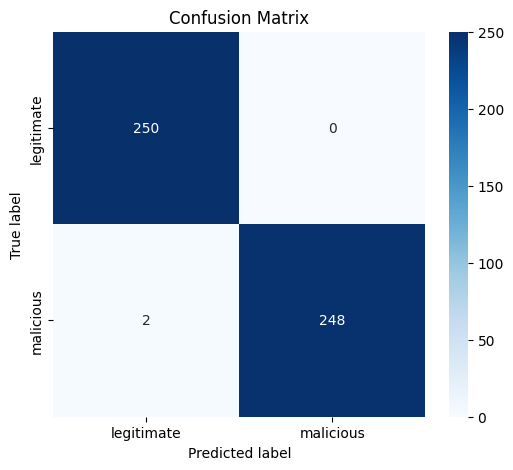


Classification Report:
              precision    recall  f1-score   support

  legitimate       0.99      1.00      1.00       250
   malicious       1.00      0.99      1.00       250

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500

ROC-AUC Score: 0.9999
Precision-Recall AUC: 0.9999


,original_url,clean_url,true_label,pred_label,status_text,final_score,phish_prob,ssl,age,reputation,domain
0,http://sunnsand.biz/pics/qgrpmkdbnfvcsxeropwkm...,http://http:/sunnsand.biz/pics/qgrpmkdbnfvcsxe...,1,1,suspicious,0.300025,0.999958,1.0,0.0,1.0,
1,http://www.efesotomasyon.com/html/ge-fanuc/VAT...,http://http:/www.efesotomasyon.com/html/ge-fan...,0,0,legitimate,0.899968,0.000053,1.0,0.0,1.0,
2,http://www.limbonganmaju.com/management/admini...,http://http:/www.limbonganmaju.com/management/...,1,1,suspicious,0.300320,0.999467,1.0,0.0,1.0,
3,http://www.payscale.com/research/US/Job=Video_...,http://http:/www.payscale.com/research/US/Job=...,0,0,legitimate,0.899985,0.000026,1.0,0.0,1.0,
4,http://www.vlsm-calc.net/models.php,http://http:/www.vlsm-calc.net/models.php,0,0,legitimate,0.899971,0.000048,1.0,0.0,1.0,
...,...,...,...,...,...,...,...,...,...,...,...
495,https://www.myrateplan.com/bundles/compare_hig...,http://https:/www.myrateplan.com/bundles/compa...,0,0,legitimate,0.699982,0.000030,0.0,0.0,1.0,
496,http://www.babysale.co.kr/technote/image/fm/ao...,http://http:/www.babysale.co.kr/technote/image...,1,1,malicious,0.100061,0.999899,0.0,0.0,1.0,
497,http://an-crimea.ru/vendor/ak_delf/korm/.git/h...,http://http:/an-crimea.ru/vendor/ak_delf/korm/...,1,1,malicious,0.100222,0.999630,0.0,0.0,1.0,
498,http://tocpublicidad.com/wp-tmp/1x/sys/wropbox...,http://http:/tocpublicidad.com/wp-tmp/1x/sys/w...,1,1,malicious,0.100029,0.999952,0.0,0.0,1.0,


In [ ]:
evaluate_csv("/content/balanced_500.csv", save_results="hybrid_eval_results.csv")

In [ ]:
print(classify_url("https://wandb.ai/authorize?ref=models"))

/tmp/ipython-input-1395434735.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return extracted.registered_domain  # e.g., google.com
/tmp/ipython-input-1602439467.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  age_days = (datetime.utcnow() - creation).days


{'url': 'https://wandb.ai/authorize?ref=models', 'domain': 'wandb.ai', 'phish_prob': 2.817498352669645e-05, 'ssl': 1.0, 'age': 0.0, 'reputation': 1.0, 'final_score': 0.899983, 'status': 'legitimate'}


In [ ]:
print(classify_url("yt118.com"))

/tmp/ipython-input-1395434735.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return extracted.registered_domain  # e.g., google.com
/tmp/ipython-input-1602439467.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  age_days = (datetime.utcnow() - creation).days


{'url': 'yt118.com', 'domain': 'yt118.com', 'phish_prob': 0.9976682066917419, 'ssl': 1.0, 'age': 0.0, 'reputation': 1.0, 'final_score': 0.301399, 'status': 'suspicious'}


In [ ]:
print(classify_url("www.google.com"))

{'url': 'www.google.com', 'domain': 'google.com', 'phish_prob': None, 'ssl': 0, 'age': 0, 'reputation': 0, 'final_score': 0.0, 'status': 'legitimate', 'reason': 'whitelisted'}


/tmp/ipython-input-1395434735.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return extracted.registered_domain  # e.g., google.com


In [ ]:
print(classify_url("www.youtube.com"))

{'url': 'www.youtube.com', 'domain': 'youtube.com', 'phish_prob': None, 'ssl': 0, 'age': 0, 'reputation': 0, 'final_score': 0.0, 'status': 'legitimate', 'reason': 'whitelisted'}


/tmp/ipython-input-1395434735.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return extracted.registered_domain  # e.g., google.com


In [ ]:
print(classify_url("www.rvu.edu.in"))

{'url': 'www.rvu.edu.in', 'domain': 'rvu.edu.in', 'phish_prob': None, 'ssl': 0, 'age': 0, 'reputation': 0, 'final_score': 0.0, 'status': 'legitimate', 'reason': 'whitelisted'}


/tmp/ipython-input-1395434735.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return extracted.registered_domain  # e.g., google.com


In [ ]:
print(classify_url("www.pythom.org"))

/tmp/ipython-input-1395434735.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return extracted.registered_domain  # e.g., google.com
/tmp/ipython-input-1602439467.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  age_days = (datetime.utcnow() - creation).days


{'url': 'www.pythom.org', 'domain': 'pythom.org', 'phish_prob': 0.00042900702101178467, 'ssl': 1.0, 'age': 0.0, 'reputation': 1.0, 'final_score': 0.899743, 'status': 'legitimate'}


In [ ]:
print(classify_url("www.efesotomasyon.com"))

/tmp/ipython-input-1395434735.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return extracted.registered_domain  # e.g., google.com
/tmp/ipython-input-1602439467.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  age_days = (datetime.utcnow() - creation).days


{'url': 'www.efesotomasyon.com', 'domain': 'efesotomasyon.com', 'phish_prob': 0.9743356704711914, 'ssl': 1.0, 'age': 0.0, 'reputation': 1.0, 'final_score': 0.315399, 'status': 'suspicious'}


In [ ]:
print(classify_url("www.vlsm-calc.net"))

/tmp/ipython-input-1395434735.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return extracted.registered_domain  # e.g., google.com
/tmp/ipython-input-1602439467.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  age_days = (datetime.utcnow() - creation).days


{'url': 'www.vlsm-calc.net', 'domain': 'vlsm-calc.net', 'phish_prob': 0.0015723230317234993, 'ssl': 1.0, 'age': 0.0, 'reputation': 1.0, 'final_score': 0.899057, 'status': 'legitimate'}


In [ ]:
print(classify_url("https://www.google.com"))

{'url': 'https://www.google.com', 'domain': 'google.com', 'phish_prob': None, 'ssl': 0, 'age': 0, 'reputation': 0, 'final_score': 0.0, 'status': 'legitimate', 'reason': 'whitelisted'}


/tmp/ipython-input-1395434735.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return extracted.registered_domain  # e.g., google.com


In [ ]:
print(classify_url("https://www.apple.com"))

/tmp/ipython-input-1395434735.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return extracted.registered_domain  # e.g., google.com
/tmp/ipython-input-1602439467.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  age_days = (datetime.utcnow() - creation).days


{'url': 'https://www.apple.com', 'domain': 'apple.com', 'phish_prob': 4.901065767626278e-05, 'ssl': 1.0, 'age': 0.0, 'reputation': 1.0, 'final_score': 0.899971, 'status': 'legitimate'}


In [ ]:
rint(classify_url("http://login-paypal.example.com"))

/tmp/ipython-input-1395434735.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  return extracted.registered_domain  # e.g., google.com
/tmp/ipython-input-1602439467.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  age_days = (datetime.utcnow() - creation).days


{'url': 'http://login-paypal.example.com', 'domain': 'example.com', 'phish_prob': 0.9999008178710938, 'ssl': 1.0, 'age': 0.0, 'reputation': 1.0, 'final_score': 0.30006, 'status': 'suspicious'}
